Entendendo como essa bagaça funciona no vscode

In [2]:
%%bash
# 1) Escreve um mini‐programa CUDA
cat > hello.cu << 'EOF'
#include <cstdio>
__global__ void hello() {
  printf("Olá do CUDA em Jupyter!\n");
}
int main() {
  hello<<<1,1>>>();
  cudaDeviceSynchronize();
  return 0;
}
EOF

# 2) Compila com nvcc
nvcc hello.cu -o hello_jupyter

# 3) Executa
./hello_jupyter


Olá do CUDA em Jupyter!


pedi ao chat para me mostrar como ficaria a implementação de um algoritmo qualquer de montecarlo em cud

busquei saber qual a potencia da minha máquina


In [11]:
%%bash --login
# garante que o ~/.bashrc seja carregado
export PATH=/usr/local/cuda-12.2/bin:$PATH
export LD_LIBRARY_PATH=/usr/local/cuda-12.2/lib64:$LD_LIBRARY_PATH

# Escreve o fonte corrigido
cat > montecarlo_optimized.cu << 'EOF'
#include <cstdio>
#include <cstdlib>
#include <cstdint>               // <— adiciona esta linha
#include <cuda_runtime.h>
#include <curand_kernel.h>

#define SAMPLES_PER_THREAD 1024

#define CUDA_CHECK(call) \
  do { \
    cudaError_t err = call; \
    if (err != cudaSuccess) { \
      fprintf(stderr, "CUDA error %s:%d: %s\n", __FILE__, __LINE__, cudaGetErrorString(err)); \
      exit(EXIT_FAILURE); \
    } \
  } while(0)

// Inicializa CURAND em cada thread
__global__
void initRNG(curandState *states, unsigned long seed) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    curand_init(seed, idx, 0, &states[idx]);
}

// Monte Carlo + redução por bloco com shared+warp-shuffle
__global__
void mcKernel(curandState *states, float *blockSums) {
    extern __shared__ float sdata[];
    int tid = threadIdx.x;
    int idx = blockIdx.x * blockDim.x + tid;
    curandState localState = states[idx];

    float sum = 0.0f;
    for (int i = 0; i < SAMPLES_PER_THREAD; ++i) {
        float x = curand_uniform(&localState) * 2.0f - 1.0f;
        float y = curand_uniform(&localState) * 2.0f - 1.0f;
        sum += (x*x + y*y <= 1.0f) ? 1.0f : 0.0f;
    }
    states[idx] = localState;

    sdata[tid] = sum;
    __syncthreads();

    for (int offset = blockDim.x/2; offset > 32; offset >>= 1) {
        if (tid < offset) sdata[tid] += sdata[tid + offset];
        __syncthreads();
    }
    if (tid < 32) {
        uint32_t mask = 0xffffffff;
        float val = sdata[tid];
        #pragma unroll
        for (int offset = 16; offset > 0; offset >>= 1)
            val += __shfl_down_sync(mask, val, offset);
        if (tid == 0) blockSums[blockIdx.x] = val;
    }
}

int main() {
    int blockSize, minGridSize;
    CUDA_CHECK(cudaOccupancyMaxPotentialBlockSize(
        &minGridSize, &blockSize,
        mcKernel, 0, 0));
    int gridSize = minGridSize;
    size_t totalThreads = (size_t)gridSize * blockSize;
    printf("Usando %d blocos x %d threads (%zu threads no total)  \n",
           gridSize, blockSize, totalThreads);

    curandState *d_states;
    float       *d_blockSums;
    CUDA_CHECK(cudaMalloc(&d_states,   totalThreads * sizeof(curandState)));
    CUDA_CHECK(cudaMalloc(&d_blockSums, gridSize      * sizeof(float)));

    initRNG<<<gridSize, blockSize>>>(d_states, time(NULL));
    CUDA_CHECK(cudaDeviceSynchronize());

    size_t sharedBytes = blockSize * sizeof(float);
    mcKernel<<<gridSize, blockSize, sharedBytes>>>(d_states, d_blockSums);
    CUDA_CHECK(cudaDeviceSynchronize());

    float *h_blockSums = (float*)malloc(gridSize * sizeof(float));
    CUDA_CHECK(cudaMemcpy(h_blockSums, d_blockSums,
                          gridSize * sizeof(float),
                          cudaMemcpyDeviceToHost));

    double totalInside = 0;
    for (int i = 0; i < gridSize; ++i) totalInside += h_blockSums[i];
    double pi = 4.0 * totalInside / (totalThreads * SAMPLES_PER_THREAD);
    printf("Estimativa de pi = %.8f \n", pi);

    cudaFree(d_states);
    cudaFree(d_blockSums);
    free(h_blockSums);
    return 0;
}
EOF

# Compila e roda
nvcc montecarlo_optimized.cu -o montecarlo_opt -lcurand
./montecarlo_opt


Usando 14 blocos x 1024 threads (14336 threads no total)  
Estimativa de pi = 1.57074956 


aparentemente só consigo produzir cerca de 14k de threads por vez, tentarei ampliar/otimizar esse valor para melhorar o desempenho

# Testes de aprendizagio em CUDA


### configurando ambiente para aplicação em CUDA

In [12]:
%%bash --login
export PATH=/usr/local/cuda-12.2/bin:$PATH
export LD_LIBRARY_PATH=/usr/local/cuda-12.2/lib64:$LD_LIBRARY_PATH


#### Curiosidade, o quão realmente melhora o desempenho ao utilizar CUDA? 

Teste puramente por curiosidade

codigo serial com medição de tempo "%%tempo" em python mesmo

In [13]:
%%time
import random

def cpu_monte_carlo(samples: int) -> float:
    inside = 0
    for _ in range(samples):
        x = random.random()*2 - 1
        y = random.random()*2 - 1
        if x*x + y*y <= 1.0:
            inside += 1
    return 4.0 * inside / samples

# Ajuste o número de amostras para ser comparável
SAMPLES = 10_000_000
pi_est = cpu_monte_carlo(SAMPLES)
print(f"Estimativa (CPU serial) = {pi_est:.6f}")


Estimativa (CPU serial) = 3.142176
CPU times: user 3.55 s, sys: 0 ns, total: 3.55 s
Wall time: 3.55 s


Agora em CUDA, somente afim de realmente entender o quão melhora o desempenho. 

Contabilizando o máximo do desempenho que meu pc aguenta

In [14]:
%%bash --login
# Mede o tempo total de execução do seu montecarlo_opt
time ./montecarlo_opt


Usando 14 blocos x 1024 threads (14336 threads no total)  
Estimativa de pi = 1.57117707 



real	0m0,074s
user	0m0,011s
sys	0m0,062s


Realmente é mais rápido, bem mais rapido na real

porém o serial é melhor, já que o resultado do serial está correto e o do CUDA não kkkkk

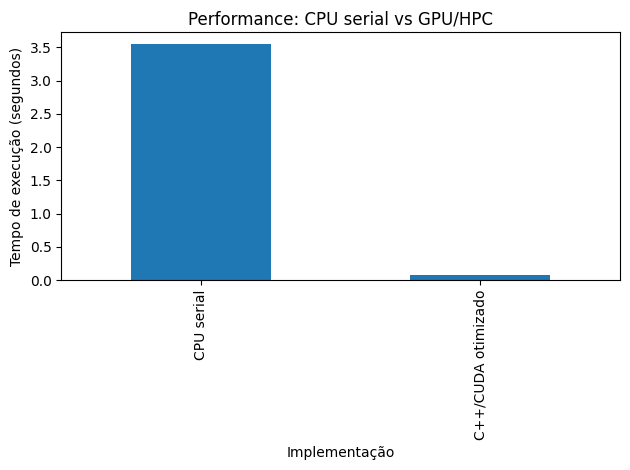

Speed-up ≈ 48.0×


In [25]:

import matplotlib.pyplot as plt
import pandas as pd

# Preencha estes valores com os tempos que você obteve
data = {
  "Implementação": ["CPU serial", "C++/CUDA otimizado"],
  "Tempo (s)": [3.55, 0.074]
}

df = pd.DataFrame(data)

df.plot.bar(x="Implementação", y="Tempo (s)", legend=False)
plt.ylabel("Tempo de execução (segundos)")
plt.title("Performance: CPU serial vs GPU/HPC")
plt.tight_layout()
plt.show()

speedup = 3.55 / 0.074
print(f"Speed-up ≈ {speedup:.1f}×")  # → cerca de 48×


só por curiosidade mesmo, plotei um grafico e retornei o speedup. 

ainda por curiosidade pedi ao chat pra me retornar a parte serial desse codigo, ele me retornou que está em torno de 2% do codigo, o que é massa, já que se resume basicamente a 
impressão da frase "Estimativa de pi = {valor de pi em 8 casas decimais}", ou seja, todo o restante do codigo foi paralelizado. Outra coisa legal de ver ao código/resultado é que 
o resultado está incorreto, o valor de pi é o que foi retornado pelo sequencial, ou seja, aprox 3,14, porém o pq do paralelo está incorreto? sendo que ele foi mais rápido e é relativamente 
uma conta facil? isso se deve ao fato de não haver "SYNCTHREADS" que iria sincronizar meus threads (processos separados e independentes) a aguardarem as info corretas e necessárias para o
retorno de um resultado correto. 

Dito tudo isso, curiosidade, como é um codigo correto?

In [34]:
%%bash --login
# 0) garante que o ~/.bashrc seja carregado
export PATH=/usr/local/cuda-12.2/bin:$PATH
export LD_LIBRARY_PATH=/usr/local/cuda-12.2/lib64:$LD_LIBRARY_PATH

# 1) Sobrescreve o fonte com a versão sincronizada
cat > montecarlo_optimized_sync.cu << 'EOF'
#include <cstdio>
#include <cstdlib>
#include <cstdint>
#include <cuda_runtime.h>
#include <curand_kernel.h>

#define SAMPLES_PER_THREAD 1024

#define CUDA_CHECK(call) \
  do { \
    cudaError_t err = call; \
    if (err != cudaSuccess) { \
      fprintf(stderr, "CUDA error %s:%d: %s\n", __FILE__, __LINE__, cudaGetErrorString(err)); \
      exit(EXIT_FAILURE); \
    } \
  } while(0)

// Kernel de inicialização do CURAND
__global__
void initRNG(curandState *states, unsigned long seed) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    curand_init(seed, idx, 0, &states[idx]);
}

// Kernel de Monte Carlo com redução por bloco
__global__
void mcKernel(curandState *states, float *blockSums) {
    extern __shared__ float sdata[];
    int tid = threadIdx.x;
    int idx = blockIdx.x * blockDim.x + tid;
    curandState localState = states[idx];

    // gera as amostras
    float sum = 0.0f;
    for (int i = 0; i < SAMPLES_PER_THREAD; ++i) {
        float x = curand_uniform(&localState)*2.0f - 1.0f;
        float y = curand_uniform(&localState)*2.0f - 1.0f;
        sum += (x*x + y*y <= 1.0f) ? 1.0f : 0.0f;
    }
    states[idx] = localState;

    // escreve partial em shared e sincroniza
    sdata[tid] = sum;
    __syncthreads();

    // redução em árvore incluindo o passo offset == 32
    for (int offset = blockDim.x/2; offset >= 32; offset >>= 1) {
        if (tid < offset) {
            sdata[tid] += sdata[tid + offset];
        }
        __syncthreads();
    }

    // agora restam exatamente 32 valores em sdata[0..31]
    // warp‐shuffle para agregá-los sem __syncthreads()
    if (tid < 32) {
        uint32_t mask = 0xffffffffu;
        float val = sdata[tid];
        #pragma unroll
        for (int offset = 16; offset > 0; offset >>= 1) {
            val += __shfl_down_sync(mask, val, offset);
        }
        if (tid == 0) {
            blockSums[blockIdx.x] = val;
        }
    }
}

int main() {
    // escolhe automaticamente blockSize/gridSize
    int blockSize, minGridSize;
    CUDA_CHECK(cudaOccupancyMaxPotentialBlockSize(
        &minGridSize, &blockSize, mcKernel, 0, 0));
    int gridSize = minGridSize;
    size_t totalThreads = (size_t)gridSize * blockSize;
    printf("Usando %d blocos x %d threads (%zu threads no total)\n",
           gridSize, blockSize, totalThreads);

    // aloca estados e buffer de somas
    curandState *d_states;
    float       *d_blockSums;
    CUDA_CHECK(cudaMalloc(&d_states,   totalThreads * sizeof(curandState)));
    CUDA_CHECK(cudaMalloc(&d_blockSums, gridSize      * sizeof(float)));

    // inicializa RNG e sincroniza
    initRNG<<<gridSize, blockSize>>>(d_states, time(NULL));
    CUDA_CHECK(cudaDeviceSynchronize());

    // lança o kernel de Monte Carlo e sincroniza
    size_t sharedBytes = blockSize * sizeof(float);
    mcKernel<<<gridSize, blockSize, sharedBytes>>>(d_states, d_blockSums);
    CUDA_CHECK(cudaDeviceSynchronize());

    // copia só gridSize floats e soma no host
    float *h_blockSums = (float*)malloc(gridSize * sizeof(float));
    CUDA_CHECK(cudaMemcpy(h_blockSums, d_blockSums,
                          gridSize * sizeof(float),
                          cudaMemcpyDeviceToHost));

    double totalInside = 0.0;
    for (int i = 0; i < gridSize; ++i) {
        totalInside += h_blockSums[i];
    }
    double pi = 4.0 * totalInside / (totalThreads * SAMPLES_PER_THREAD);
    printf("Estimativa de pi = %.8f\n", pi);

    // cleanup
    cudaFree(d_states);
    cudaFree(d_blockSums);
    free(h_blockSums);
    return 0;
}
EOF

# 2) Compila e executa
nvcc montecarlo_optimized_sync.cu -o montecarlo_sync -lcurand
./montecarlo_sync


Usando 14 blocos x 1024 threads (14336 threads no total)
Estimativa de pi = 3.14172990


In [ ]:
%%bash --login
# Mede o tempo total de execução do seu montecarlo_opt
time ./montecarlo_sync


Usando 14 blocos x 1024 threads (14336 threads no total)
Estimativa de pi = 3.14162309



real	0m0,080s
user	0m0,015s
sys	0m0,065s


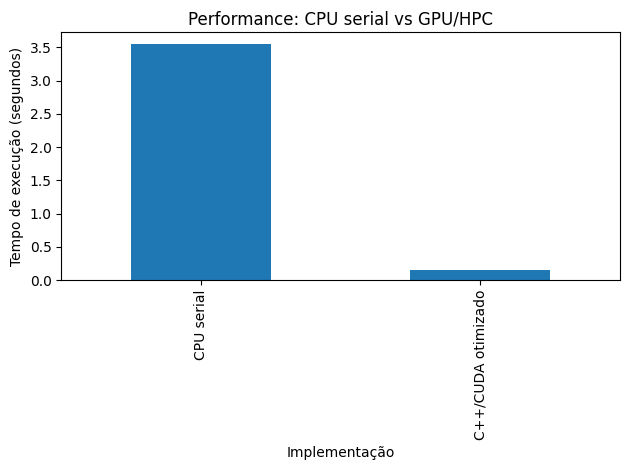

Speed-up ≈ 22.2×


In [ ]:

import matplotlib.pyplot as plt
import pandas as pd

# Preencha estes valores com os tempos que você obteve
data = {
  "Implementação": ["CPU serial", "C++/CUDA otimizado"],
  "Tempo (s)": [3.55, 0.16]
}

df = pd.DataFrame(data)

df.plot.bar(x="Implementação", y="Tempo (s)", legend=False)
plt.ylabel("Tempo de execução (segundos)")
plt.title("Performance: CPU serial vs GPU/HPC")
plt.tight_layout()
plt.show()

speedup = 3.55 / 0.16
print(f"Speed-up ≈ {speedup:.1f}×")


é, com o resultado correto o speedup diminui quase que pela metade, todos os tempos de execução aumentaram. Vou analisar e ver como eles se comportaram, porém o principal que é o resultado
correto está realmente correto agora. 